In [2]:
import pandas as pd
import numpy as np
import nltk as nlp
import matplotlib.pyplot as plt
import re
from nltk.probability import FreqDist
import math
from collections import Counter

In [7]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-


def get_TTR(questions):
    # List to store the TTR values
    TTR_List = []
    # List to store the ID of the article
    Article_Number = []
    for counter in range(len(questions)):
        document = questions[counter]
        # Remove all special characters using this regex
        document = re.sub(r"[^\w]", " ", document)
        # Convert Document to Lower Case
        document = document.lower()

        tokens = nlp.word_tokenize(document)
        total_tokens = len(tokens)
        freq_dist = FreqDist(tokens)
        num_types = len(freq_dist)
        if total_tokens > 0:
            normalized_ttr = num_types / math.sqrt(total_tokens)
        else:
            normalized_ttr = num_types

        TTR = normalized_ttr
        # Append TTR to TTR_List
        TTR_List.append(TTR)
        # Append counter to Article_Number
        Article_Number.append(counter)

    return np.mean(TTR_List)
    """
    # Draw Scatter Plot of Article_Number vs TTR 
    plt.scatter(Article_Number,TTR_List)
    # Draw Connecting Line Plot of Article_Number vs TTR
    plt.plot(Article_Number,TTR_List)
    plt.xlabel("Article Number")
    plt.ylabel("TTR Score")
    plt.show()
    """

In [12]:
def distinct_n(examples, n):
    counter = Counter()
    n_total = 0
    n_distinct = 0
    for example in examples:
        gen = example.split()
        for token in zip(*(gen[i:] for i in range(n))):
            if token not in counter:
                n_distinct += 1
            elif counter[token] == 1:
                n_distinct -= 1
            counter[token] += 1
            n_total += 1
    return n_distinct, n_total

In [4]:
df = pd.read_csv("../test/genai_questions_809156896092057937.csv")
questions = df["questions"].to_list()

ttr = get_TTR(questions)
print(ttr)

n_distinct, n_total = distinct_n(questions, 1)
print(n_distinct, n_total, n_distinct / n_total)

n_distinct, n_total = distinct_n(questions, 2)
print(n_distinct, n_total, n_distinct / n_total)

n_distinct, n_total = distinct_n(questions, 3)
print(n_distinct, n_total, n_distinct / n_total)

4.221936387548589
417 14071 0.02963542036813304
1715 13379 0.12818596307646313
3007 12687 0.23701426657208166


In [13]:
df = pd.read_csv("../test/genai_questions_bank_windturbinegearbox_llama_390922363128910063.csv")
questions = df["questions"].to_list()

ttr = get_TTR(questions)
print(ttr)

n_distinct, n_total = distinct_n(questions, 1)
print(n_distinct, n_total, n_distinct / n_total)

n_distinct, n_total = distinct_n(questions, 2)
print(n_distinct, n_total, n_distinct / n_total)

n_distinct, n_total = distinct_n(questions, 3)
print(n_distinct, n_total, n_distinct / n_total)


4.4849614329601115
391 6687 0.058471661432630474
1567 6436 0.24347420758234928
2686 6185 0.43427647534357317


In [5]:
df = pd.read_csv("./existing_qa_datasets/squad_v2_q.csv")
questions = df["question"].to_list()

ttr = get_TTR(questions)
print(ttr)

n_distinct, n_total = distinct_n(questions, 1)
print(n_distinct, n_total, n_distinct / n_total)

n_distinct, n_total = distinct_n(questions, 2)
print(n_distinct, n_total, n_distinct / n_total)

n_distinct, n_total = distinct_n(questions, 3)
print(n_distinct, n_total, n_distinct / n_total)

3.0336399396182836
35949 1289353 0.027881425800382054
299248 1159034 0.25818742159418967
563680 1028717 0.5479446728303313


In [6]:
df = pd.read_csv("./existing_qa_datasets/hotpot_q.csv")
questions = df["question"].to_list()

ttr = get_TTR(questions)
print(ttr)

n_distinct, n_total = distinct_n(questions, 1)
print(n_distinct, n_total, n_distinct / n_total)

n_distinct, n_total = distinct_n(questions, 2)
print(n_distinct, n_total, n_distinct / n_total)

n_distinct, n_total = distinct_n(questions, 3)
print(n_distinct, n_total, n_distinct / n_total)

3.8043800202440656
82220 1611621 0.05101695746084222
445243 1521174 0.29269695642970495
821309 1430727 0.5740501157802991


In [8]:
df = pd.read_csv("./existing_qa_datasets/nq_open_q.csv")
questions = df["question"].to_list()

ttr = get_TTR(questions)
print(ttr)

n_distinct, n_total = distinct_n(questions, 1)
print(n_distinct, n_total, n_distinct / n_total)

n_distinct, n_total = distinct_n(questions, 2)
print(n_distinct, n_total, n_distinct / n_total)

n_distinct, n_total = distinct_n(questions, 3)
print(n_distinct, n_total, n_distinct / n_total)

2.917275336636215
13787 796900 0.017300790563433303
126175 708975 0.17796819351881238
254855 621050 0.4103614845825618


In [9]:
df = pd.read_csv("./existing_qa_datasets/web_questions_q.csv")
questions = df["question"].to_list()

ttr = get_TTR(questions)
print(ttr)

n_distinct, n_total = distinct_n(questions, 1)
print(n_distinct, n_total, n_distinct / n_total)

n_distinct, n_total = distinct_n(questions, 2)
print(n_distinct, n_total, n_distinct / n_total)

n_distinct, n_total = distinct_n(questions, 3)
print(n_distinct, n_total, n_distinct / n_total)

2.553891474771784
2420 25236 0.09589475352670787
7968 21458 0.37133004007829246
11339 17680 0.6413461538461539


In [10]:
f = open(
    "C:\\Users\\1J1870897\\Documents\\GitHub\\AutoQA\\autorecipe\\kddexp\\benchmarks\\reactagent\\wind_turbine\\train10_100_DSprompt.txt",
    "r",
)
X = f.read()

X = X.split("\n")
questions = [x.split(" ", 1)[1] for x in X]

ttr = get_TTR(questions)
print(ttr)

n_distinct, n_total = distinct_n(questions, 1)
print(n_distinct, n_total, n_distinct / n_total)

n_distinct, n_total = distinct_n(questions, 2)
print(n_distinct, n_total, n_distinct / n_total)

n_distinct, n_total = distinct_n(questions, 3)
print(n_distinct, n_total, n_distinct / n_total)

2.7082614779940832
11 752 0.014627659574468085
40 652 0.06134969325153374
53 552 0.09601449275362318


In [11]:
f = open(
    "C:\\Users\\1J1870897\\Documents\\GitHub\\AutoQA\\autorecipe\\kddexp\\benchmarks\\reactagent\\wind_turbine\\trail9_100_DS_prompt.txt",
    "r",
)
X = f.read()

X = X.split("\n")
questions = [x.split(" ", 1)[1] for x in X]

ttr = get_TTR(questions)
print(ttr)

n_distinct, n_total = distinct_n(questions, 1)
print(n_distinct, n_total, n_distinct / n_total)

n_distinct, n_total = distinct_n(questions, 2)
print(n_distinct, n_total, n_distinct / n_total)

n_distinct, n_total = distinct_n(questions, 3)
print(n_distinct, n_total, n_distinct / n_total)

2.7816196001938738
51 889 0.05736782902137233
134 789 0.16983523447401774
231 689 0.3352685050798258


In [15]:
# running time computations
path = "C:\\Users\\1J1870897\\Documents\\GitHub\\AutoQA\\autorecipe\\kddexp\\benchmarks\\reactagent\\wind_turbine\\"
files = [
    "trail9_100_DS_prompt.txt",
    "train10_100_DSprompt.txt",
    "trial1_250.txt",
    "trial2_250.txt",
    "trial8_100.txt",
    "dprob_trial1_100_DS_prompt.txt",
    "dprob_trial2_100_DS_prompt_think.txt",
    "dprob_trial3_100_DS_prompt.txt",
    "genai_questions_bank_windturbinegearbox_llama_390922363128910063.csv",
    #"genai_questions_311016922297059474.csv",
    #"genai_questions_809156896092057937.csv",
]

SampleResults = []

for file in files:

    if '.csv' in file:
        X = pd.read_csv(path + file)
        questions = X['questions'].to_list()
    else:
        f = open(
            path + file,
            "r",
        )
        X = f.read()

        X = X.split("\n")
        questions = [x.split(" ", 1)[1] for x in X]

    batch_size = 20
    print (f'processing - {file}')

    #n_distinct, n_total = distinct_n(questions, 2)
    #print(n_distinct, n_total, n_distinct / n_total)

    # Iterate through the list in batches
    for i in range(0, len(questions), batch_size):
        batch = questions[0:i + batch_size]       
        ttr = get_TTR(batch)
        n_distinct, n_total = distinct_n(batch, 2)
        SampleResults.append([file, n_distinct, n_total, n_distinct / n_total, ttr, len(batch)])
        #print(n_distinct, n_total, n_distinct / n_total, ttr, len(batch))

processing - trail9_100_DS_prompt.txt
processing - train10_100_DSprompt.txt
processing - trial1_250.txt
processing - trial2_250.txt
processing - trial8_100.txt
processing - dprob_trial1_100_DS_prompt.txt
processing - dprob_trial2_100_DS_prompt_think.txt
processing - dprob_trial3_100_DS_prompt.txt
processing - genai_questions_bank_windturbinegearbox_llama_390922363128910063.csv


In [16]:
Rset = ['file', 'n_distinct', 'n_total', 'distinct-2', 'ttr', 'batch']
ans = pd.DataFrame(SampleResults, columns=Rset)
print (ans)

                                                 file  n_distinct  n_total  \
0                            trail9_100_DS_prompt.txt          12      164   
1                            trail9_100_DS_prompt.txt          24      335   
2                            trail9_100_DS_prompt.txt          36      499   
3                            trail9_100_DS_prompt.txt          78      627   
4                            trail9_100_DS_prompt.txt         134      789   
5                            train10_100_DSprompt.txt           9      123   
6                            train10_100_DSprompt.txt          17      258   
7                            train10_100_DSprompt.txt          29      377   
8                            train10_100_DSprompt.txt          38      509   
9                            train10_100_DSprompt.txt          40      652   
10                                     trial1_250.txt          86      221   
11                                     trial1_250.txt         11

In [17]:
import plotly.graph_objects as go

# Sample DataFrame (replace this with your actual DataFrame)
# df = ...
df = ans

fig = go.Figure()

# Define markers and line styles
markers = ['circle', 'square', 'diamond', 'cross', 'x']
lines = ['solid']

# Iterate through unique files in the DataFrame
for i, file in enumerate(df['file'].unique()):
    file_data = df[df['file'] == file]
    marker_style = markers[i % len(markers)]
    line_style = lines[i % len(lines)]
    
    fig.add_trace(go.Scatter(
        x=file_data['batch'],
        y=file_data['distinct-2'],
        mode='lines+markers',
        name=file,
        text=file,
        line=dict(dash=line_style),
        marker=dict(symbol=marker_style, size=10),
    ))

# Update layout
fig.update_layout(
    xaxis_title='# of Questions',
    yaxis_title='Distinct-2',
    font=dict(family="Times New Roman", size=12),
    legend=dict(
        orientation="h",  # Horizontal orientation
        yanchor="top",  # Anchor to the bottom
        y=1.02,  # Adjust the position vertically
        xanchor="left",  # Anchor to the right
        x=1,  # Adjust the position horizontally
    ),
    xaxis=dict(
        showgrid=False,  # Do not show grid for x-axis
        tickvals=list(range(0, max(df['batch']) + 1, 20)),  # Set tick values with a step of 20
    ),
    yaxis=dict(
        showgrid=False,  # Do not show grid for y-axis
    ),
    plot_bgcolor='white',  # Set background color for the entire plot
)

# Show the plot
fig.show()


In [18]:
ans.to_csv('intro_exp.csv',index=False)

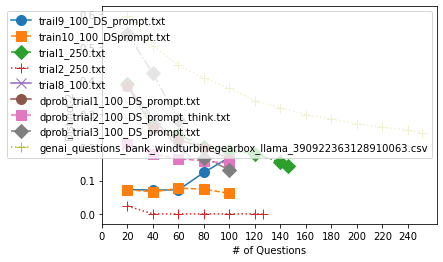

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

# Sample DataFrame (replace this with your actual DataFrame)
# df = ...
df = ans

# Define markers and line styles
markers = ['o', 's', 'D', '+', 'x']
lines = ['-', '--', '-.', ':', '-']

# Set up the figure and axis
fig, ax = plt.subplots()

# Iterate through unique files in the DataFrame
for i, file in enumerate(df['file'].unique()):
    file_data = df[df['file'] == file]
    marker_style = markers[i % len(markers)]
    line_style = lines[i % len(lines)]

    ax.plot(
        file_data['batch'],
        file_data['distinct-2'],
        label=file,
        linestyle=line_style,
        marker=marker_style,
        markersize=10,
    )

# Set axis labels and title
ax.set_xlabel('# of Questions')
ax.set_ylabel('Distinct-2')
#ax.set_title('Your Title Here')

# Set x-axis ticks with a step of 20
ax.set_xticks(range(0, max(df['batch']) + 1, 20))

# Display legend
ax.legend()

# Set background color for the entire plot
ax.set_facecolor('white')

# Remove grid
ax.grid(False)

plt.savefig('trials.png')

# Show the plot
plt.show()


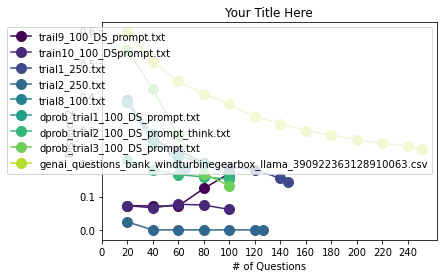

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

# Sample DataFrame (replace this with your actual DataFrame)
# df = ...
df = ans

# Set up the figure and axis
fig, ax = plt.subplots()

# Iterate through unique files in the DataFrame
for i, file in enumerate(df['file'].unique()):
    file_data = df[df['file'] == file]
    color = plt.cm.viridis(i / len(df['file'].unique()))  # Use a colormap to get different colors
    ax.plot(
        file_data['batch'],
        file_data['distinct-2'],
        label=file,
        linestyle='-',
        marker='o',
        markersize=10,
        color=color,
    )

# Set axis labels and title
ax.set_xlabel('# of Questions')
ax.set_ylabel('Distinct-2')
ax.set_title('Your Title Here')

# Set x-axis ticks with a step of 20
ax.set_xticks(range(0, max(df['batch']) + 1, 20))

# Display legend
ax.legend()

# Set background color for the entire plot
ax.set_facecolor('white')

# Show the plot
plt.show()


In [8]:
ttr = get_TTR(['TDM-Santos-MacDonald said the<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<'])
print(ttr)


0.0


In [22]:
ans = 'TDM-Santos-MacDonald said the<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<'

for item in ans.split(' '):
    print (len(item))


20
4
474


In [43]:
import re

def trim_repeated_right_side(sentence, max_repetitions):
    # Define the regex pattern to match repeated occurrences of the last letter
    pattern = re.compile(rf'({re.escape(sentence[-1])})\1{{{max_repetitions - 1},}}$')

    # Trim the right side by replacing repeated occurrences with a single occurrence
    result_word = pattern.sub(sentence[-1], sentence)

    return result_word

def trim_repeated_right_side_word(sentence):
    """_summary_

    :param sentence: _description_
    :type sentence: _type_
    :return: _description_
    :rtype: _type_
    """
    words = sentence.split(' ')
    pos = len(words)
    for i in range(len(words)):
        if words[len(words)-i-1] != words[len(words)-i-2]:
            break
        pos = pos - 1
    fset = ' '.join(words[:pos])
    return fset

# Example usage
ans = "this is a test test test test"
ans = 'TDM-Santos-MacDonald said the<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<'
input_word = ans

# Trim consecutive repeated letters on the right side if more than 5 times
result_word = trim_repeated_right_side(input_word, max_repetitions=2)

print("Original Word:", input_word)
print("Result Word:", result_word)
print ("Remaining String:", len(result_word)*100.0/len(input_word))

result_word = trim_repeated_right_side_word(result_word)
print("Original Word:", input_word)
print("Result Word:", result_word)
print ("Remaining String:", len(result_word)*100.0/len(input_word))



Original Word: TDM-Santos-MacDonald said the<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
Result Word: TDM-Santos-MacDonald said the<
Remaining String: 6.0
Original Word: TDM-Santos-MacDonald said the<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<